In [52]:
import numpy as np
import pandas as pd

In [94]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = np.where(cancer.target == 0, -1, 1)

In [95]:
from sklearn.preprocessing import StandardScaler
se = StandardScaler()

In [96]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [97]:
# X_train = se.fit_transform(X_train)
# X_test = se.fit_transform(X_test)

In [98]:
svm = SVC(kernel="linear", C=1)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [99]:
y_pred = svm.predict(X_test)

In [100]:
from sklearn.metrics import accuracy_score

In [101]:
accuracy_score(y_test,y_pred)

0.9035087719298246

In [145]:
# using batch gd
class SVM: 
    def __init__(self, learning_rate=0.001, lambda_param=0.01, epochs=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

    def fit(self, X_train, y_train):
        n_samples, n_features = X_train.shape
        y_ = np.where(y_train <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):
            for idx,x_i in enumerate(X_train):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b)

                if condition >= 1:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y_[idx] * x_i)
                    self.b += self.lr * y_[idx]

    def predict(self, X_test):
        return np.sign(np.dot(X_test, self.w) + self.b)

In [146]:
svm = SVM(learning_rate=0.001, lambda_param=0.01, epochs=1000)

In [147]:
svm.fit(X_train,y_train)

In [148]:
y_pred = svm.predict(X_test)
accuracy_score(y_test, y_pred)

0.9210526315789473

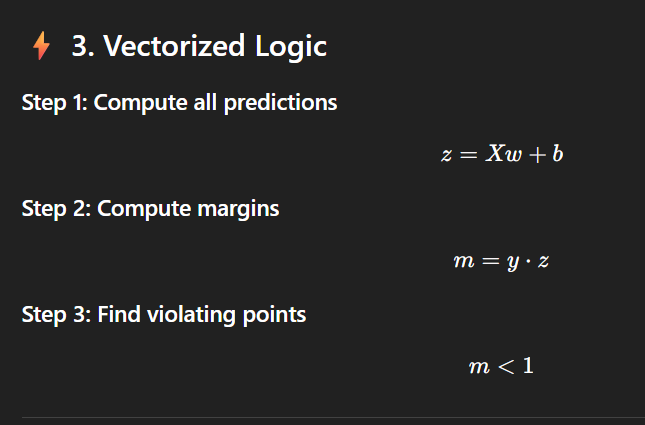

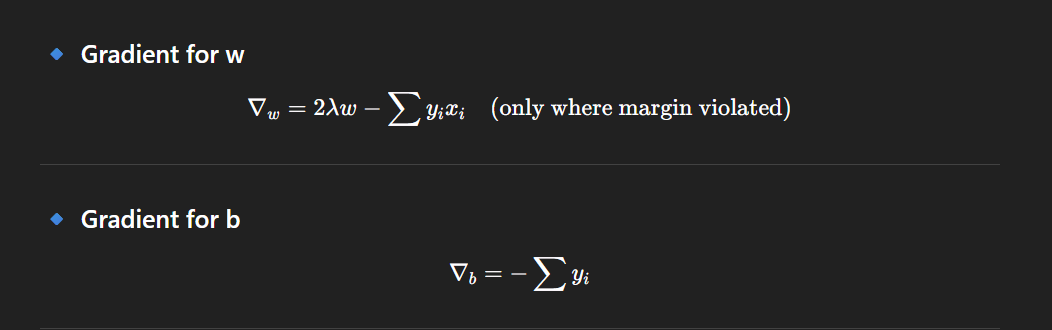

In [137]:
## svm using vectorize
class SVM_: 
    def __init__(self, learning_rate=0.001, lambda_param=0.01, epochs=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

    def fit(self, X_train, y_train):
        n_samples, n_features = X_train.shape
        y_ = np.where(y_train <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):
            linear_output = np.dot(X, self.w) + self.b

            # Step 2: margins
            margins = y * linear_output

            # Step 3: find misclassified / inside margin
            condition = margins < 1

            # ---- gradients ----
            dw = 2 * self.lambda_param * self.w - np.dot(X[condition].T, y[condition])
            db = -np.sum(y[condition])

            # ---- update ----
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

In [138]:
svm = SVM_(learning_rate=0.001, lambda_param=0.01, epochs=1000)

In [139]:
svm.fit(X_train,y_train)

In [140]:
y_pred = svm.predict(X_test)
accuracy_score(y_test, y_pred)

0.631578947368421